# Ray Unit 0 - Objects

## Setup

Use the same environment and kernel as in the previous notebook.


## 0. Mental model

Ordinary Python lets us mostly ignore memory management:
- call a function
- get a value back
- keep moving

In cluster computing, that luxury weakens.

Once values can cross **process boundaries** and **node boundaries**, we must care about:
1. where the data lives
2. when copies are made

In Ray, we address these explicitly:
- A **Ray object** is an **immutable** value stored in the **distributed object store**.
- An **`ObjectRef`** is a reference to that value.
- There may exist many copies, on various nodes, of a single object. 

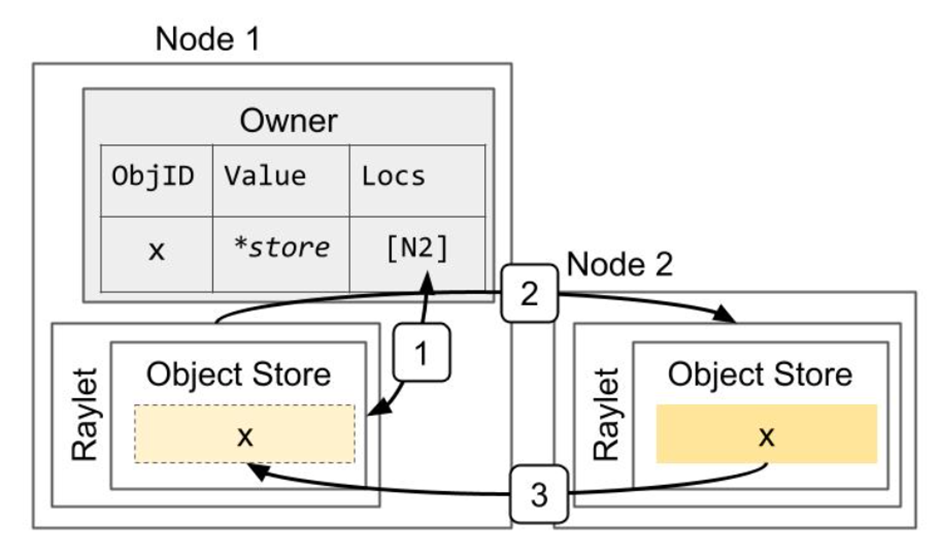
Source: [Ray whitepaper](https://docs.google.com/document/d/1tBw9A4j62ruI5omIJbMxly-la5w4q_TjyJgJL_jN2fI)

1. The driver (on node 1) ran `x = f.remote()` and got an ObjectRef.
2. the task was scheduled and ran on node 2. The return value was produced and stored locally. 
3. The worker called `ray.get(x)` and a local copy on node 1 was created. 



In [69]:
import time
import numpy as np
import ray

## 1. Start a local Ray cluster

In [70]:
ray.shutdown()
ray.init()

2026-03-22 19:49:18,526	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8266 


Python version:,3.12.13
Ray version:,2.54.0
Dashboard:,http://127.0.0.1:8266


## 2. Creating objects explicitly with `ray.put(...)`

There are two standard ways to get an `ObjectRef`:
1. `x = f.remote()` - invoking a remote function that will eventually return a value.
2. `x = ray.put(...)` - storing an object in the store explicitly.

In [71]:
small_obj = {
    'course': '22971',
    'part': 'ray',
    'topics': ['async', 'objects', 'ownership'],
}

small_ref = ray.put(small_obj)

print('Reference:', small_ref)
print('Type:', type(small_ref))

Reference: ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000037e1f505)
Type: <class 'ray.ObjectRef'>


`small_ref` is **not** the dictionary. It is a handle to a dictionary stored in Ray's object store.

Fetch the value explicitly with `ray.get(...)`.


In [72]:
small_val = ray.get(small_ref)
print(small_val)
print(type(small_val))

{'course': '22971', 'part': 'ray', 'topics': ['async', 'objects', 'ownership']}
<class 'dict'>


## 3. Remote objects are immutable

Ray objects in the object store are immutable.

This does **not** mean the Python value you get back from `ray.get(...)` cannot be mutated locally.
It means the **stored remote object** is not mutated in place.

`ray.get(...)` usually creates a local copy. Mutating this local copy **does not rewrite** the object in the store.


In [73]:
d1 = ray.get(small_ref)
d2 = ray.get(small_ref)

d1['course'] = 'changed-locally'

print('First local copy :', d1)
print('Second local copy:', d2)
print('Fresh fetch       :', ray.get(small_ref))

First local copy : {'course': 'changed-locally', 'part': 'ray', 'topics': ['async', 'objects', 'ownership']}
Second local copy: {'course': '22971', 'part': 'ray', 'topics': ['async', 'objects', 'ownership']}
Fresh fetch       : {'course': '22971', 'part': 'ray', 'topics': ['async', 'objects', 'ownership']}


**Conclusion**: the object store still holds the original value.

## 4. `ray.get([ref1, ref2, ...])` fetches many objects

In [74]:
many_refs = [ray.put(i) for i in range(3)]
print('ObjectRef Array:')
print(many_refs)
print('\nMany objects:')
print(ray.get(many_refs))

ObjectRef Array:
[ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000038e1f505), ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000039e1f505), ObjectRef(00ffffffffffffffffffffffffffffffffffffff010000003ae1f505)]

Many objects:
[0, 1, 2]


**Note**: this blocks until all objects are available locally.

## 5. Passing object arguments

`ObjectRef`s can be passed around freely as task arguments.

### Top-level vs nested arguments

When an `ObjectRef` is passed as a **top-level argument**, Ray **de-references it automatically** before the task starts.

When an `ObjectRef` is passed **inside** a Python container, Ray does **not** de-reference it automatically. The task sees the reference itself.

In [75]:
@ray.remote
def inspect_args(x, x_arr, x_dict):
    return {
        'top_level_type': type(x).__name__,
        'array_inner_type': type(x_arr[0]).__name__,
        'array_preview': repr(x_arr[0]),
        'dict_inner_type': type(x_dict[0]).__name__,
        'dict_preview': repr(x_dict[0]),
    }

a = ray.put(123)
ray.get(inspect_args.remote(a, [a], {0:a}))

{'top_level_type': 'int',
 'array_inner_type': 'ObjectRef',
 'array_preview': 'ObjectRef(00ffffffffffffffffffffffffffffffffffffff010000003be1f505)',
 'dict_inner_type': 'ObjectRef',
 'dict_preview': 'ObjectRef(00ffffffffffffffffffffffffffffffffffffff010000003be1f505)'}

Interpretation:

- top-level `ObjectRef` → the task receives the **value**
- nested `ObjectRef` → the task receives the **reference**

### Experiment #1: top-level ObjectRef

In [76]:
@ray.remote
def slow_producer():
    start = time.perf_counter()
    time.sleep(3)
    elapsed = time.perf_counter() - start
    print(f"Elapsed (in producer): {elapsed:.2f} seconds")
    return 123


@ray.remote
def top_consumer(x):
    start = time.perf_counter()
    elapsed = time.perf_counter() - start
    print(f"Elapsed (in top_consumer): {elapsed:.2f} seconds")
    return x

# --- Experiment 1: top-level argument (implicit dependency)
start = time.perf_counter()
ref = slow_producer.remote()
top_ref = top_consumer.remote(ref)
print("Submitted top-level consumer")
print(f"Elapsed (submission): {time.perf_counter() - start:.2f} seconds")

out = ray.get(top_ref)

elapsed = time.perf_counter() - start
time.sleep(0.1)
print("Result (top):", out)
print(f"Elapsed (final): {elapsed:.2f} seconds")

Submitted top-level consumer
Elapsed (submission): 0.01 seconds
(slow_producer pid=21304) Elapsed (in producer): 3.00 seconds
(top_consumer pid=21304) Elapsed (in top_consumer): 0.00 seconds
Result (top): 123
Elapsed (final): 3.02 seconds


### What happens under the hood

1. Both tasks are submitted immediately to the scheduler (raylet).
2. The raylet records that `top_consumer` depends on `ref` → task is **not runnable yet**.
3. `slow_producer` finishes and writes its result to the object store.
4. The raylet marks the dependency as resolved → `top_consumer` becomes **runnable**.
5. `top_consumer` is scheduled to run.
6. `top_consumer` runs instantly (no waiting inside the task).

**Key idea:** tasks don’t block — they are held back until their inputs exist.

### Experiment #2: nested ObjectRef

In [ ]:
@ray.remote
def nested_consumer(x_ref):
    start = time.perf_counter()
    x = ray.get(x_ref[0])   # explicit blocking inside the task
    elapsed = time.perf_counter() - start
    print(f"Elapsed (in nested_consumer): {elapsed:.2f} seconds")

    return x

# --- Experiment 2: nested argument (manual get inside task)

start = time.perf_counter()

ref = slow_producer.remote()
nested_ref = nested_consumer.remote([ref])

print("Submitted nested consumer")
print(f"Elapsed (submission): {time.perf_counter() - start:.2f} seconds")

out = ray.get(nested_ref)
elapsed = time.perf_counter() - start
time.sleep(0.1)
print("Result (nested):", out)
print(f"Elapsed (final): {elapsed:.2f} seconds")

Submitted nested consumer
Elapsed (submission): 0.00 seconds
(slow_producer pid=21304) Elapsed (in producer): 3.00 seconds
(nested_consumer pid=27072) Elapsed (in nested_consumer): 2.91 seconds
Result (nested): [123]
Elapsed (final): 3.02 seconds


### Under the hood (nested ObjectRef)

1. Both tasks are submitted immediately to the scheduler (raylet).
2. `nested_consumer` receives `[ref]` as a **regular Python object** → no scheduling dependency is registered.
3. The raylet sees no dependency → both tasks are **runnable** and may be scheduled.
4. `nested_consumer` starts executing on a worker.
5. Inside the task, `ray.get(...)` is called.
6. The worker **blocks**, waiting for the underlying object.
7. `slow_producer` finishes and writes its result to the object store.
8. `nested_consumer` unblocks once the object is ready and continues execution.

**Key idea:** with nested ObjectRefs, the dependency is not enforced at scheduling time — the waiting happens inside the task.

**Takeaway:** In most ML workloads, nested `ObjectRef`s are an anti-pattern. If a task depends on an upstream result, pass the `ObjectRef` at the top level so Ray can schedule it efficiently.

## 6. Serialization and copy cost

In [ ]:
#Restart the cluster to wipe the object store.
ray.shutdown()
ray.init()

2026-03-22 20:24:04,858	INFO worker.py:2004 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8266 


Python version:,3.12.13
Ray version:,2.54.0
Dashboard:,http://127.0.0.1:8266


### Experiment #1: passing plain Python objects to a remote function
With each invocation a new (identical) object is serialized and stored.

In [102]:
@ray.remote
def payload_size(x):
    return len(x)

blob = b'x' * 10_000_000   # 10 MB
num_tasks = 8

start = time.perf_counter()
sizes_by_value = ray.get([payload_size.remote(blob) for _ in range(num_tasks)])
elapsed_by_value = time.perf_counter() - start

print('Sample output     :', sizes_by_value[:3])
print(f'By-value elapsed  : {elapsed_by_value:.3f} s')

Sample output     : [10000000, 10000000, 10000000]
By-value elapsed  : 0.270 s


### Experiment #2: passing a reference to a Ray object
The object is stored once and reused by all invocations.

In [103]:
blob_ref = ray.put(blob)

start = time.perf_counter()
sizes_by_ref = ray.get([payload_size.remote(blob_ref) for _ in range(num_tasks)])
elapsed_by_ref = time.perf_counter() - start

print('Sample output     :', sizes_by_ref[:3])
print(f'By-ref elapsed    : {elapsed_by_ref:.3f} s')
print(f'Speedup factor    : {elapsed_by_value / elapsed_by_ref:.2f}x')

Sample output     : [10000000, 10000000, 10000000]
By-ref elapsed    : 0.022 s
Speedup factor    : 12.04x


### Under the hood:
1. Run in a shell: `ray memory`
    - There should be a single 10MB object, that's `blob_ref`.
2. Now run:

In [104]:
@ray.remote
def payload_size_slow(x):
    time.sleep(30)
    return len(x)
sizes_by_value = ray.get([payload_size_slow.remote(blob) for _ in range(num_tasks)])

3. and then `ray memory` again, **while the cell is running**. You should see:
     - `blob_ref`
     - up to 8 more 10MB copies of `blob`, depending on how many tasks are running concurrently on your machine.
4. run `ray memory` again, after **execution**. 
    - The 8 copies are gone: The tasks finished running and these **unreferenced** objects were freed.

**Takeaway**: Think about the memory footprint and store objects explicitly.

## 7. NumPy arrays: zero-copy reads on the same node

Ray optimizes NumPy arrays.

When you run `ray.get(ndarray_ref)`:
1. Ray fetches it (if it does not exist yet on this node).
2. A **read-only view** backed by shared object-store memory is returned. 

In [105]:
arr = np.arange(10, dtype=np.float64)
arr_ref = ray.put(arr)
arr_from_ray = ray.get(arr_ref)

print(arr_from_ray)
print('writeable:', arr_from_ray.flags.writeable)
print('base is None:', arr_from_ray.base is None) #Owns the memory buffer?

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
writeable: False
base is None: False


In [106]:
try:
    arr_from_ray[0] = -1.0
except ValueError as e:
    print(type(e).__name__ + ':', e)

ValueError: assignment destination is read-only


If you need to mutate it, **copy it first.**

In [107]:
arr_local = arr_from_ray.copy()
arr_local[0] = -1.0
print('writeable:', arr_local.flags.writeable)
print('base is None:', arr_local.base is None)
print('Copied and mutated:', arr_local)
print('Original in store :', ray.get(arr_ref))

writeable: True
base is None: True
Copied and mutated: [-1.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
Original in store : [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


## 8. Summary

1. A **Ray object** is an immutable value stored in the distributed object store.
2. An **`ObjectRef`** is the handle used to refer to that value.
3. `ray.get(...)` fetches the value behind one or more refs.
4. Passing data in Ray has real **serialization** and **copy** costs.
5. Top-level refs are de-referenced automatically; nested refs are not.
6. NumPy arrays are special: same-node reads can be zero-copy and read-only.

## 9. Optional exercises

1. Create a list of `ObjectRef`s with `ray.put(...)`, then place that list itself in the object store.
   - What does one `ray.get(...)` return?
   - Retrieve the original object.
2. Define a remote function that receives both:
   - one top-level `ObjectRef`
   - one list containing that same `ObjectRef`
   
   Invoke the function and find out:
   1. When is the task `runnable`? 
   2. In the scope of the task,  what's the data type of both arguments? 

3. Repeat the serialization/copy-cost timing experiment with a range of payload sizes and more tasks.
   - When does the difference become noticeable on your machine?

4. Repeat the serialization/copy-cost timing experiment with 10MB NumPy arrays.
   - Is there a noticeable difference?

In [ ]:
ray.shutdown()